# Titanic Dataset Analysis

## Part 1: Data Preparation

In this section, we load the Titanic `train` and `test` datasets, concatenate them into a single DataFrame, and perform necessary type conversions (categorical and boolean) for further analysis.

In [150]:
import pandas as pd
test_titanic = pd.read_csv('test.csv')
train_titanic = pd. read_csv('train.csv')

dat_fr = pd.concat([train_titanic, test_titanic], axis = 0, ignore_index = True)
dat_fr = pd.DataFrame(data = dat_fr)

dat_fr['Survived'] = pd.Categorical(dat_fr['Survived'])
dat_fr['Pclass'] = pd.Categorical(dat_fr['Pclass'], categories = [1, 2, 3], ordered = True)
dat_fr['Sex'] = pd.Categorical(dat_fr['Sex'])
dat_fr['Survived'] = dat_fr['Survived'].astype(bool)
dat_fr

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,False,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,True,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,True,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,True,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,False,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


## Part 2: Table Analysis

### 2.1. Basic Statistics
**Question:** Which class had the most passengers?

In [151]:
class_count = dat_fr['Pclass'].value_counts()
class_count

Pclass
3    709
1    323
2    277
Name: count, dtype: int64

### 2.2. Grouping by Class and Sex
**Question:** Grouping by Class and Sex, who is the youngest and who is the oldest on average? What is the difference?

In [152]:
grouped_by_age = dat_fr.groupby(['Pclass', 'Sex'], observed = False)['Age'].mean()
grouped_by_age

Pclass  Sex   
1       female    37.037594
        male      41.029272
2       female    27.499223
        male      30.815380
3       female    22.185329
        male      25.962264
Name: Age, dtype: float64

In [153]:
youngest_age = grouped_by_age.min()
oldest_age = grouped_by_age.max()
youngest_idx = grouped_by_age.idxmin()
oldest_idx = grouped_by_age.idxmax()
print(f"The youngest group on Titanic was: {youngest_idx[1]} from {youngest_idx[0]} class. Their average age was {youngest_age}")
print(f"The oldest group on Titanic was: {oldest_idx[1]} from {oldest_idx[0]} class. Their average age was {oldest_age}")
print(f"Age difference - {oldest_age - youngest_age}")

The youngest group on Titanic was: female from 3 class. Their average age was 22.185328947368422
The oldest group on Titanic was: male from 1 class. Their average age was 41.02927152317881
Age difference - 18.843942575810384


**Answer:**
Based on the code output above:
*   The **youngest group** consists of Females from the 3rd class.
*   The **oldest group** consists of Males from the 1st class.

### 2.3. Survivors with surname starting with "K"
**Question:** Among survivors whose names start with "K", who paid the most and who paid the least?

In [154]:
k_surv = dat_fr[(dat_fr['Survived'] == True) & (dat_fr['Name'].str.startswith('K'))].copy()
k_surv_sorted = k_surv.sort_values('Fare', ascending = False)
print(f"{k_surv_sorted.iloc[0]['Name']} paid more then everyone - {k_surv_sorted.iloc[0]['Fare']}")
print(f"{k_surv_sorted.iloc[-1]['Name']} paid less then everyone - {k_surv_sorted.iloc[-1]['Fare']}")

Kimball, Mr. Edwin Nelson Jr paid more then everyone - 52.5542
Kelly, Miss. Mary paid less then everyone - 7.75


### 2.4. Relatives Analysis
**Question:** What was the maximum number of relatives (SibSp + Parch) associated with a survived passenger?

In [165]:
survived = dat_fr[dat_fr['Survived'] == True]
dat_fr['allRelatives'] = dat_fr['Parch'] + dat_fr['SibSp']
max_relatives = survived['allRelatives'].max()
print(f"Max relatives with the person was: {max_relatives}")

Max relatives with the person was: 6


## Part 3: Visualization

In this section, we visualize the data using Plotly, Matplotlib, and Seaborn.

### 3.1. Scatter Plot: Cost vs. Age (Interactive)
Visualizing the dependence of ticket cost on age, colored by survival status.

In [156]:
import plotly.express as px

graph1 = px.scatter(dat_fr, x = 'Age', y = 'Fare', color = 'Survived',
                    size = 'Pclass', hover_data = ['Name', 'Sex'],
                    title = "Dependence of cost on age")
graph1.show()

### 3.2. Histogram: Age Distribution (Interactive)
Distribution of passengers by age, colored by sex.

In [157]:
graph2 = px.histogram(dat_fr, x = 'Age', color = 'Sex', nbins = 30,
                      title = 'distribution by age')
graph2.show()

### 3.3. Bar Chart: Survival Count by Class and Sex (Seaborn)
A static bar chart showing the absolute count of survivors grouped by class and sex.

/tmp/ipykernel_9462/101999797.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



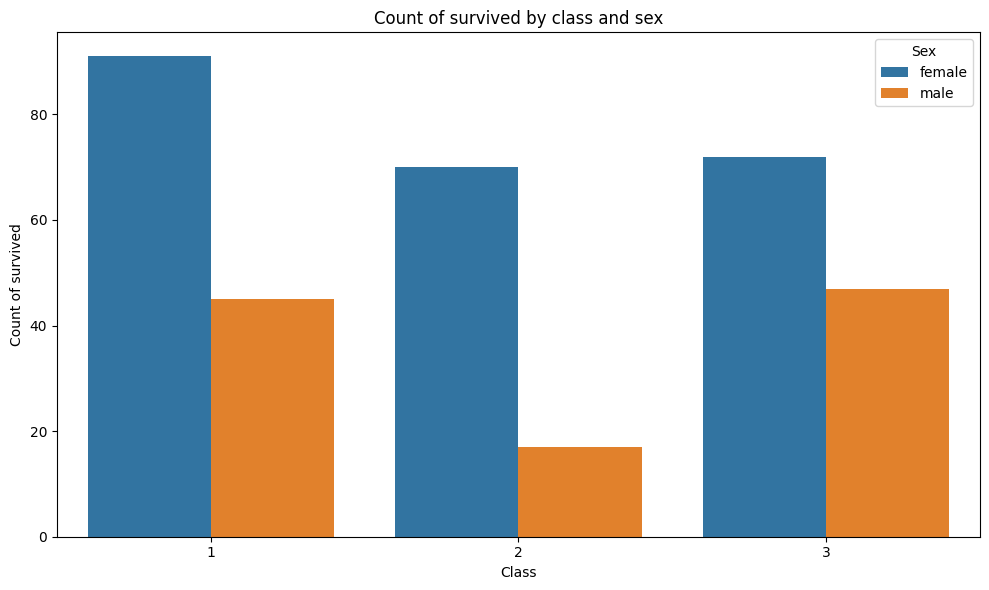

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns
survival_stats = dat_fr.groupby(['Pclass', 'Sex'])['Survived'].apply(lambda x: (x == True).sum()).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=survival_stats, x='Pclass', y='Survived', hue='Sex')
plt.title('Count of survived by class and sex')
plt.xlabel('Class')
plt.ylabel('Count of survived')
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

### 3.4. Horizontal Bar Chart: Top 10 Ticket Prices
Visualizing the passengers who paid the highest fares.

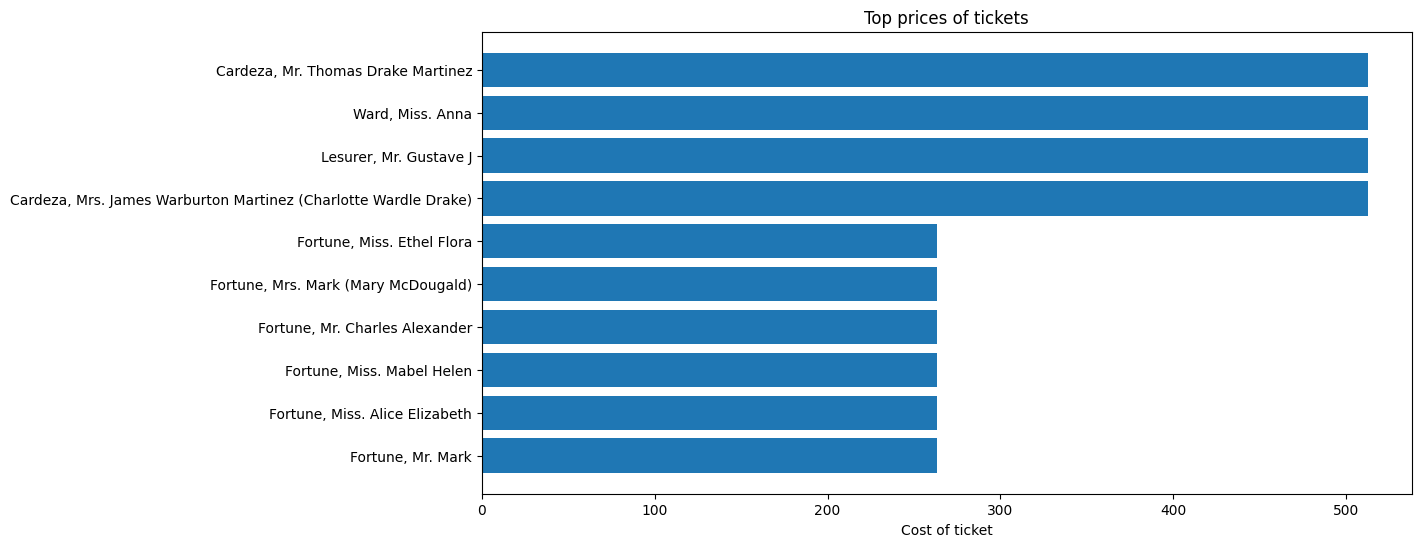

In [159]:
top_ticket_prices = dat_fr.nlargest(10, 'Fare')[['Name', 'Fare']].sort_values('Fare')
plt.figure(figsize=(12, 6))
plt.barh(range(len(top_ticket_prices)), top_ticket_prices['Fare'])
plt.yticks(range(len(top_ticket_prices)), [name for name in top_ticket_prices['Name']])
plt.xlabel('Cost of ticket')
plt.title('Top prices of tickets')
plt.show()

### 3.5. Pie Chart: Class Distribution (Interactive)
Showing the proportion of passengers in each class.

In [160]:
class_distribution = dat_fr['Pclass'].value_counts()
graph5 = px.pie(values=class_distribution.values, names=class_distribution.index,
              title='Distribution by class')
graph5.show()

### 3.6. Sunburst Chart: Survivability Hierarchy (Interactive)
Hierarchical view of survivors by Class, then Sex, then Survival status.

In [161]:
survived_data = dat_fr.dropna(subset = ['Survived'])
graph6 = px.sunburst(survived_data, path=['Pclass', 'Sex', 'Survived'],
                   title='Survivability by class')
graph6.show()

### 3.7. 3D Scatter Plot (Interactive)
3D visualization comparing Age, Ticket Cost, and Number of Relatives.

In [162]:
import plotly.graph_objects as go
dat_fr['Survived'] = pd.Categorical(dat_fr['Survived'])

graph7 = go.Figure(data = [go.Scatter3d(x = dat_fr['Age'], y = dat_fr['Fare'], z = dat_fr['allRelatives'], mode = 'markers',
    marker=dict(size = 5, color = dat_fr ['Survived'].cat.codes, colorscale = 'Viridis', showscale = True, colorbar =dict (title="survived")), text = dat_fr['Name'], hovertemplate='<b>%{text}</b><br>age: %{x}<br>cost: %{y}<br>relatives: %{z}<extra></extra>')])

graph7.update_layout(title='3D visualisation: age, cost af ticket and quantity of relatives',
    scene = dict(xaxis_title = 'Age', yaxis_title = 'cost of ticket', zaxis_title = 'quantity of relatives'))
graph7.show()

# Classification and Dimensionality Reduction on Iris Dataset

In [187]:
from sklearn import datasets

iris = datasets.load_iris()
iris_df = pd.DataFrame(data = iris.data, columns = iris.feature_names)
iris_df['species'] = iris.target_names[iris.target]

X = iris.data
y = iris.target
target_names = iris.target_names

X_memory = X.nbytes
y_memory = y.nbytes
total_memory = X_memory + y_memory

print(f"Occupied space: {total_memory} bytes")

Occupied space: 6000 bytes


### 1.2. Normalization
We normalize the data to the range [0, 1] for each column using the Min-Max scaling formula:
$$ X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}} $$

In [172]:
import numpy as np

X_normalized = np.zeros_like(X)

for col in range(X.shape[1]):
    min_val = np.min(X[:, col])
    max_val = np.max(X[:, col])
    X_normalized[:, col] = (X[:, col] - min_val) / (max_val - min_val)

X_normalized

array([[0.22222222, 0.625     , 0.06779661, 0.04166667],
       [0.16666667, 0.41666667, 0.06779661, 0.04166667],
       [0.11111111, 0.5       , 0.05084746, 0.04166667],
       [0.08333333, 0.45833333, 0.08474576, 0.04166667],
       [0.19444444, 0.66666667, 0.06779661, 0.04166667],
       [0.30555556, 0.79166667, 0.11864407, 0.125     ],
       [0.08333333, 0.58333333, 0.06779661, 0.08333333],
       [0.19444444, 0.58333333, 0.08474576, 0.04166667],
       [0.02777778, 0.375     , 0.06779661, 0.04166667],
       [0.16666667, 0.45833333, 0.08474576, 0.        ],
       [0.30555556, 0.70833333, 0.08474576, 0.04166667],
       [0.13888889, 0.58333333, 0.10169492, 0.04166667],
       [0.13888889, 0.41666667, 0.06779661, 0.        ],
       [0.        , 0.41666667, 0.01694915, 0.        ],
       [0.41666667, 0.83333333, 0.03389831, 0.04166667],
       [0.38888889, 1.        , 0.08474576, 0.125     ],
       [0.30555556, 0.79166667, 0.05084746, 0.125     ],
       [0.22222222, 0.625     ,

### 1.3. Feature Discretization
We transform one of the continuous features (e.g., the first feature) into a categorical variable ('small', 'medium', 'big') based on quartiles ($Q1$ and $Q3$).

In [179]:
feature_idx = 0
feature_name = iris.feature_names[feature_idx]
feature_data = X_normalized[:, feature_idx]

q25 = np.percentile(feature_data, 25)
q75 = np.percentile(feature_data, 75)

categorical_feature = np.empty(len(feature_data), dtype=object)
categorical_feature[feature_data < q25] = 'small'
categorical_feature[(feature_data >= q25) & (feature_data <= q75)] = 'medium'
categorical_feature[feature_data > q75] = 'big'

### 1.4. Train/Test Split
We split the dataset into random train (80%) and test (20%) subsets using numpy indices.

In [188]:
np.random.seed(42)

n_samples = X_normalized.shape[0]
indices = np.arange(n_samples)
np.random.shuffle(indices)

split_idx = int(0.8 * n_samples)
train_indices = indices[:split_idx]
test_indices = indices[split_idx:]

X_train = X_normalized[train_indices]
X_test = X_normalized[test_indices]
y_train = y[train_indices]
y_test = y[test_indices]

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 120
Test set size: 30


### 2. Support Vector Machine (SVM) Experiments

In this section, we will train different SVM models to compare their performance.

#### 2.1. Experiment 1: Base Model (RBF Kernel, Normalized Data)
We start with the base model using the Radial Basis Function (RBF) kernel on the normalized data.

Base Model Accuracy: 0.9667 (96.67%)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         7
  versicolor       0.92      1.00      0.96        11
   virginica       1.00      0.92      0.96        12

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



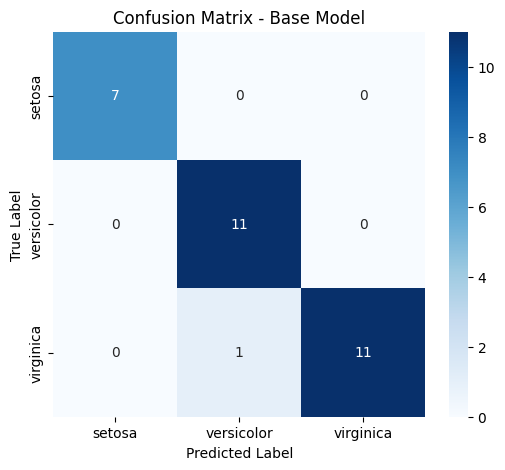

In [212]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

model_base = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
model_base.fit(X_train, y_train)

y_pred_base = model_base.predict(X_test)

acc_base = accuracy_score(y_test, y_pred_base)
accuracy_1 = acc_base

print(f"Base Model Accuracy: {acc_base:.4f} ({acc_base*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_base, target_names=target_names))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Base Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

#### 2.2. Experiment 2: Unnormalized Data
Now check how the model performs without data normalization. We use the raw indices to get the original data.


Model Accuracy: 0.9667 (96.67%)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         7
  versicolor       0.92      1.00      0.96        11
   virginica       1.00      0.92      0.96        12

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



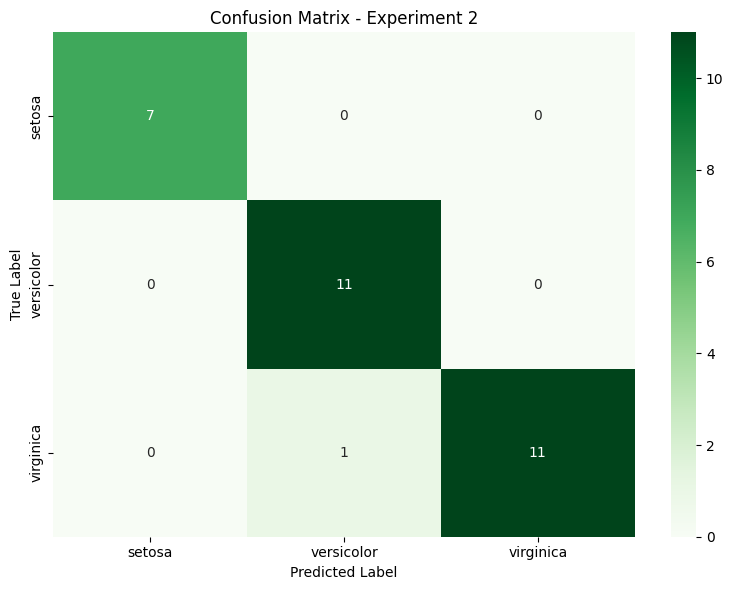

In [200]:
X_train_raw = X[train_indices]
X_test_raw = X[test_indices]
#Training
model_2 = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
model_2.fit(X_train_raw, y_train)

# Prediction and evaluation
y_pred_2 = model_2.predict(X_test_raw)
accuracy_2 = accuracy_score(y_test, y_pred_2)

print(f"\nModel Accuracy: {accuracy_2:.4f} ({accuracy_2*100:.2f}%)")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_2, target_names=target_names))

# Confusion Matrix
cm_2 = confusion_matrix(y_test, y_pred_2)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Greens', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Experiment 2')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

**Comparison:** Normalized data: accuracy `accuracy_1`, Unnormalized data: `accuracy_2`.

**Conclusion:** Data normalization may improve or maintain the results depending on the specific dataset structure. In many cases with SVM, normalization is crucial because SVM is sensitive to the scale of the features.

#### 2.3. Experiment 3: SVC with Linear Kernel
Here we change the kernel from RBF to Linear to see if the data is linearly separable.


Model Accuracy: 0.9667 (96.67%)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         7
  versicolor       0.92      1.00      0.96        11
   virginica       1.00      0.92      0.96        12

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



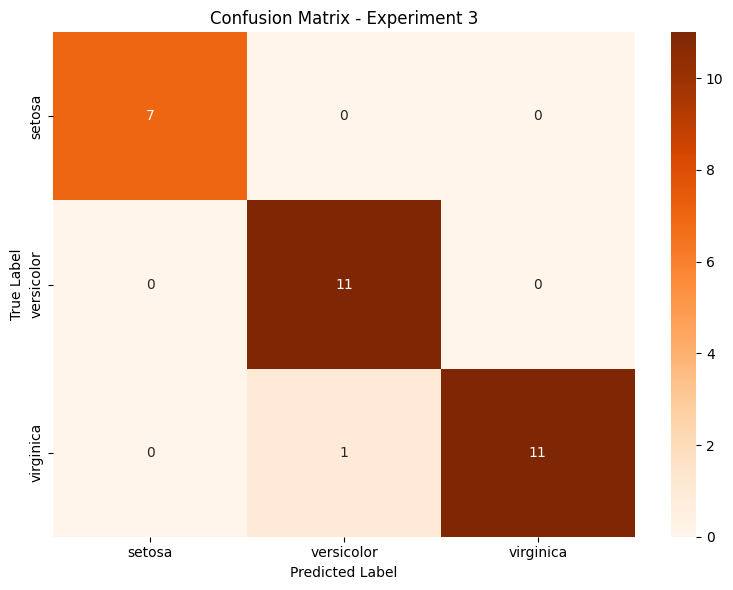

In [203]:
model_3 = SVC(kernel='linear', C=1.0, random_state=42)
model_3.fit(X_train, y_train)

y_pred_3 = model_3.predict(X_test)
accuracy_3 = accuracy_score(y_test, y_pred_3)

print(f"\nModel Accuracy: {accuracy_3:.4f} ({accuracy_3*100:.2f}%)")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_3, target_names=target_names))

cm_3 = confusion_matrix(y_test, y_pred_3)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_3, annot=True, fmt='d', cmap='Oranges', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Experiment 3')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

**Conclusion:** The linear kernel might perform worse if the data is not linearly separable. If the accuracy is high, it suggests the classes can be separated by a straight line (or hyperplane).

#### 2.4. Experiment 4: SVC with Increased C Parameter
We increase the regularization parameter C to 10. This attempts to classify more training points correctly but might lead to overfitting.


Model Accuracy: 1.0000 (100.00%)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         7
  versicolor       1.00      1.00      1.00        11
   virginica       1.00      1.00      1.00        12

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



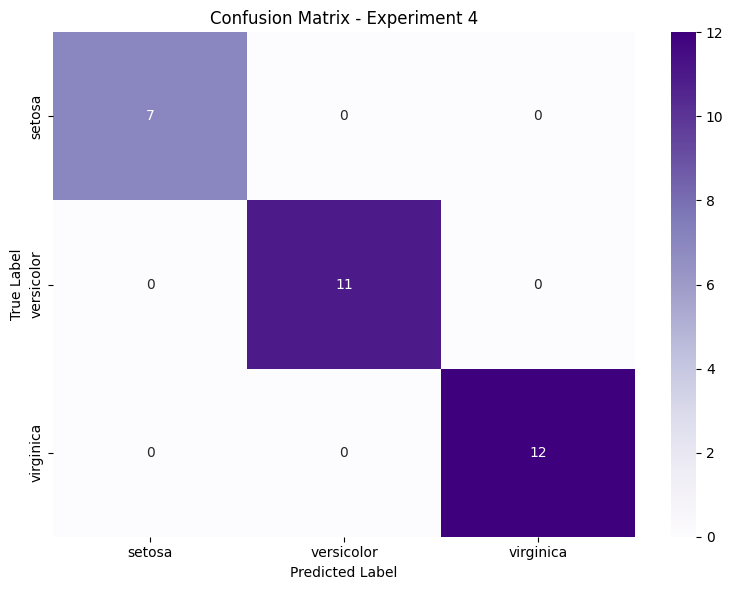

In [213]:
model_4 = SVC(kernel='rbf', C=10.0, gamma='scale', random_state=42)
model_4.fit(X_train, y_train)

y_pred_4 = model_4.predict(X_test)
accuracy_4 = accuracy_score(y_test, y_pred_4)

print(f"\nModel Accuracy: {accuracy_4:.4f} ({accuracy_4*100:.2f}%)")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_4, target_names=target_names))

cm_4 = confusion_matrix(y_test, y_pred_4)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_4, annot=True, fmt='d', cmap='Purples',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Experiment 4')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

**Conclusion:** Increasing the parameter C makes the model strictly penalize misclassifications, making it more sensitive to outliers.

### 2.5. Summary of Experiments
Comparing the results of all models.

Exp. 1: RBF kernel, normalized: 0.9667 (96.67%)
Exp. 2: RBF kernel, unnormalized: 0.9667 (96.67%)
Exp. 3: Linear kernel, normalized: 0.9667 (96.67%)
Exp. 4: RBF kernel (C=10), normalized: 1.0000 (100.00%)

**Best Result:** Exp. 4: RBF kernel (C=10), normalized with accuracy 1.0000


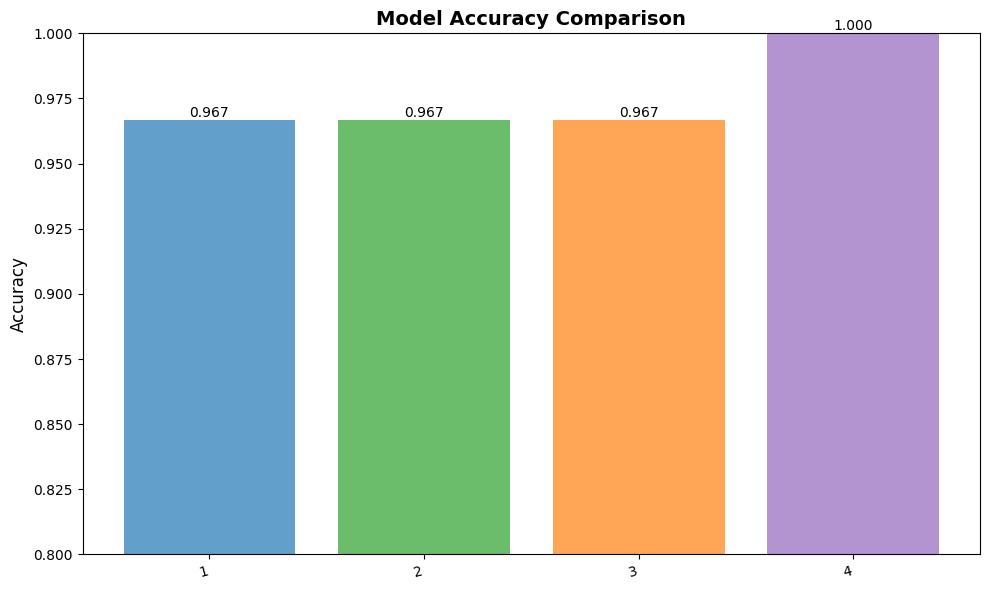

In [206]:
experiments = [
    ("Exp. 1: RBF kernel, normalized", accuracy_1),
    ("Exp. 2: RBF kernel, unnormalized", accuracy_2),
    ("Exp. 3: Linear kernel, normalized", accuracy_3),
    ("Exp. 4: RBF kernel (C=10), normalized", accuracy_4),
]

for name, acc in experiments:
    print(f"{name}: {acc:.4f} ({acc*100:.2f}%)")

best_exp = max(experiments, key=lambda x: x[1])
print(f"\n**Best Result:** {best_exp[0]} with accuracy {best_exp[1]:.4f}")

# Visualization
plt.figure(figsize=(10, 6))
names = [e[0].replace("Exp. ", "").split(":")[0] for e in experiments]
accuracies = [e[1] for e in experiments]
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd']
bars = plt.bar(names, accuracies, color=colors, alpha=0.7)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylim(0.8, 1.0)
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=10)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## Part 3: Visualization with Dimensionality Reduction

### 3.1. PCA - Principal Component Analysis

Explained variance ratio: [0.84136038 0.11751808]
Total explained variance: 0.9589


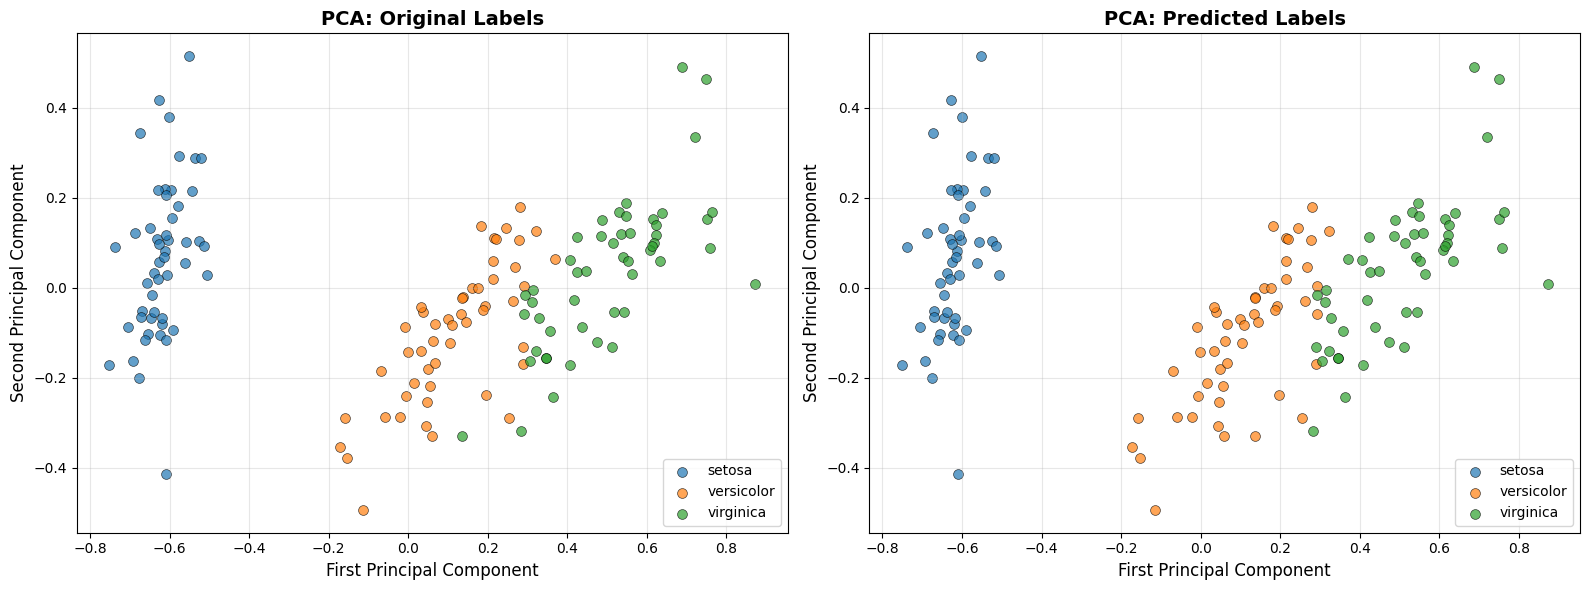

In [208]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_normalized)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {sum(pca.explained_variance_ratio_):.4f}")

y_pred_full = model_base.predict(X_normalized)

# Create subplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, name in enumerate(target_names):
    mask = y == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   label=name, alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('First Principal Component', fontsize=12)
axes[0].set_ylabel('Second Principal Component', fontsize=12)
axes[0].set_title('PCA: Original Labels', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

for i, name in enumerate(target_names):
    mask = y_pred_full == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   label=name, alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('First Principal Component', fontsize=12)
axes[1].set_ylabel('Second Principal Component', fontsize=12)
axes[1].set_title('PCA: Predicted Labels', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

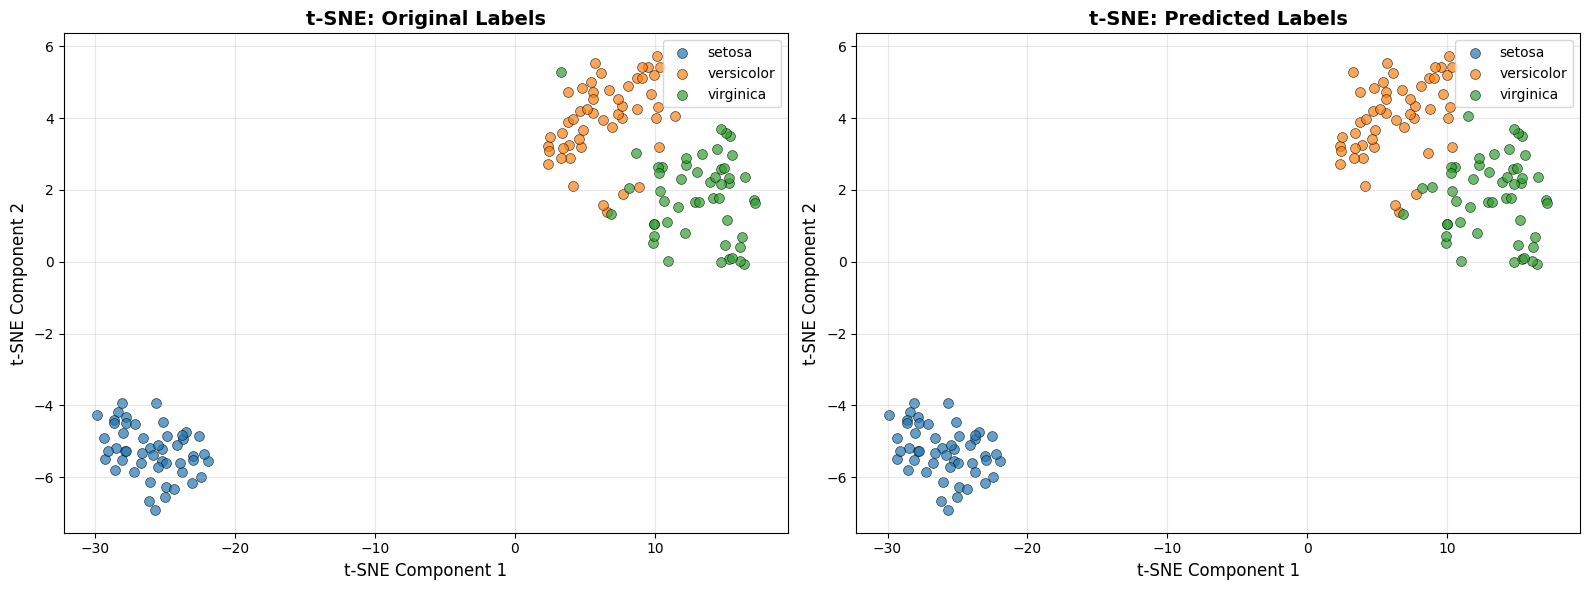

In [216]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_normalized)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Original Labels
for i, name in enumerate(target_names):
    mask = y == i
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=name, alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('t-SNE Component 1', fontsize=12)
axes[0].set_ylabel('t-SNE Component 2', fontsize=12)
axes[0].set_title('t-SNE: Original Labels', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

for i, name in enumerate(target_names):
    mask = y_pred_full == i
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],  label=name, alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('t-SNE Component 1', fontsize=12)
axes[1].set_ylabel('t-SNE Component 2', fontsize=12)
axes[1].set_title('t-SNE: Predicted Labels', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()